<a href="https://colab.research.google.com/github/FayselN/soda-bottle-detection-yolov8/blob/main/yolo_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="T995OvIMt4crQOUYgNE1")
project = rf.workspace("faysels-workspace").project("soda-bottles-zygh-1j24c")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to soda-bottles-zygh-1 in yolov8:: 100%|██████████| 6074/6074 [00:01<00:00, 5408.70it/s]


In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.6 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
DATASET_PATH = "/content/soda-bottles-zygh-1"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print(DATA_YAML)

/content/soda-bottles-zygh-1/data.yaml


In [5]:
model = YOLO("yolov8n.pt")   # nano version (fast)

In [6]:
metrics_before = model.val(data=DATA_YAML)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2439.4±818.8 MB/s, size: 80.2 KB)
val: Scanning /content/soda-bottles-zygh-1/valid/labels... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449 1.8Kit/s 0.3s
val: New cache created: /content/soda-bottles-zygh-1/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.0it/s 7.2s
                   all        449      10949     0.0429     0.0415     0.0242     0.0133
                person        435       3812     0.0892      0.118     0.0527     0.0278
               bicycle        439       3441     0.0176   0.000872    0.00892    0.00478
                   car        440       3696     0.0218    0.00568     0.0109    0.00739
Speed: 1.6ms preprocess, 4.3ms inference, 0.0ms loss, 1.5ms

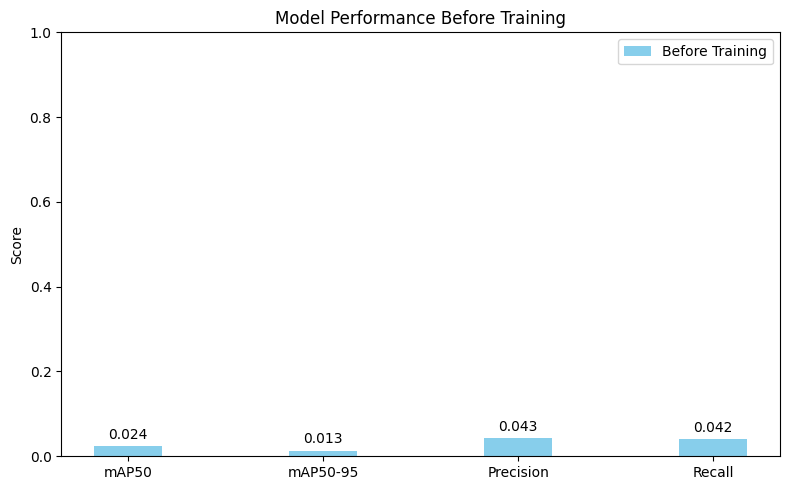

In [7]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_before_values = [
    metrics_before.box.map50,
    metrics_before.box.map,
    metrics_before.box.mp,
    metrics_before.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_before_values, width, label='Before Training', color='skyblue')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [8]:
results = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name="yolov8_custom"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/soda-bottles-zygh-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [9]:
trained_model = YOLO("/content/runs/detect/yolov8_custom/weights/best.pt")

metrics_after = trained_model.val(data=DATA_YAML)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1814.2±452.1 MB/s, size: 71.9 KB)
val: Scanning /content/soda-bottles-zygh-1/valid/labels.cache... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449 144.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.4it/s 8.5s
                   all        449      10949      0.936      0.925      0.953      0.541
             coca-cola        435       3812      0.942      0.916      0.952      0.538
                 fanta        439       3441      0.932      0.936      0.958      0.556
                sprite        440       3696      0.934      0.922      0.949       0.53
Speed: 1.7ms preprocess, 3.9ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val2


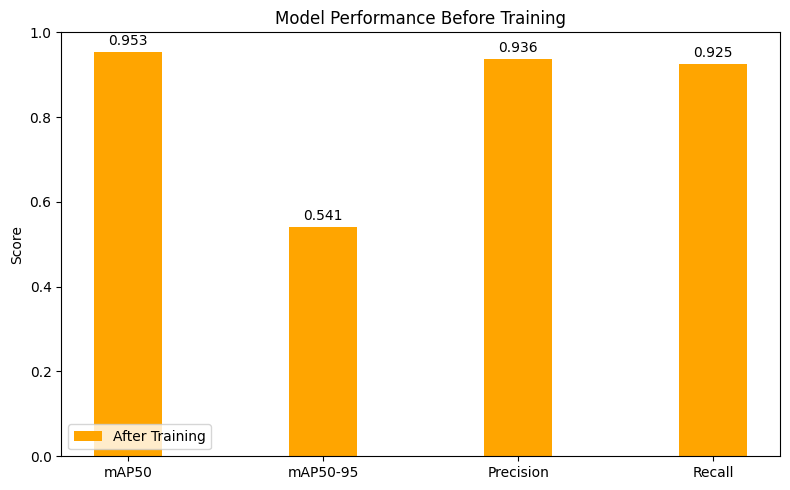

In [10]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_after_values = [
    metrics_after.box.map50,
    metrics_after.box.map,
    metrics_after.box.mp,
    metrics_after.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_after_values, width, label='After Training', color='Orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [11]:
print("\n===== PERFORMANCE COMPARISON =====")

print("mAP50 BEFORE :", metrics_before.box.map50)
print("mAP50 AFTER  :", metrics_after.box.map50)

print("mAP50-95 BEFORE :", metrics_before.box.map)
print("mAP50-95 AFTER  :", metrics_after.box.map)

print("Precision BEFORE :", metrics_before.box.mp)
print("Precision AFTER  :", metrics_after.box.mp)

print("Recall BEFORE :", metrics_before.box.mr)
print("Recall AFTER  :", metrics_after.box.mr)


===== PERFORMANCE COMPARISON =====
mAP50 BEFORE : 0.02417452216670316
mAP50 AFTER  : 0.9530914712192069
mAP50-95 BEFORE : 0.013341296393447015
mAP50-95 AFTER  : 0.5414285589540372
Precision BEFORE : 0.04286275500385783
Precision AFTER  : 0.9359845175537144
Recall BEFORE : 0.04153397546290956
Recall AFTER  : 0.924597777214211



image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220315_153849_bmp_jpg.rf.5373c86ef6ffb9944b34a9639189cbf7.jpg: 640x640 9 coca-colas, 9 fantas, 16 sprites, 18.7ms
Speed: 2.2ms preprocess, 18.7ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


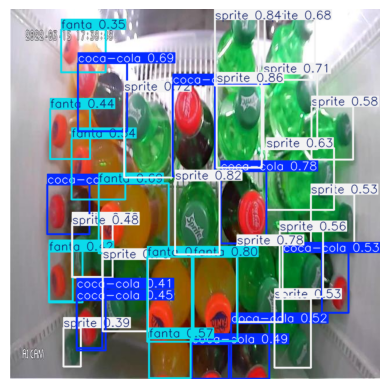


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220317_141551_bmp_jpg.rf.d02d5e04f9bf29e7525b8d0558da81c0.jpg: 640x640 4 coca-colas, 4 fantas, 4 sprites, 21.3ms
Speed: 2.3ms preprocess, 21.3ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


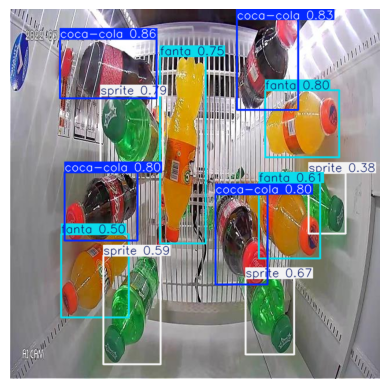


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220318_130848_bmp_jpg.rf.cacad0dd09e7c0e4ca7e0cb05f130423.jpg: 640x640 4 coca-colas, 5 fantas, 6 sprites, 32.9ms
Speed: 3.4ms preprocess, 32.9ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)


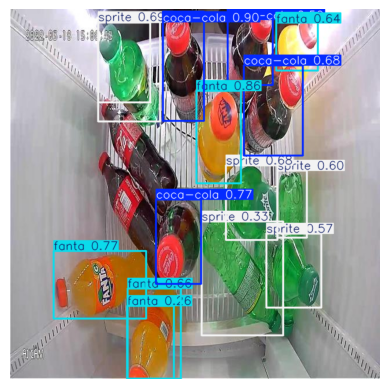


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220317_132403_bmp_jpg.rf.783f8a09e6e3233f677f59187ee0d248.jpg: 640x640 4 coca-colas, 5 fantas, 4 sprites, 8.6ms
Speed: 2.6ms preprocess, 8.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


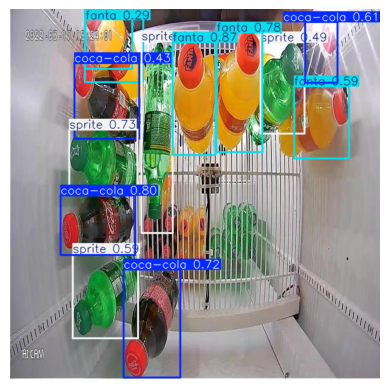


image 1/1 /content/soda-bottles-zygh-1/test/images/01_20220317_144946_bmp_jpg.rf.50ab17020832187f15ec2392829a19a5.jpg: 640x640 2 coca-colas, 2 fantas, 2 sprites, 13.4ms
Speed: 2.2ms preprocess, 13.4ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


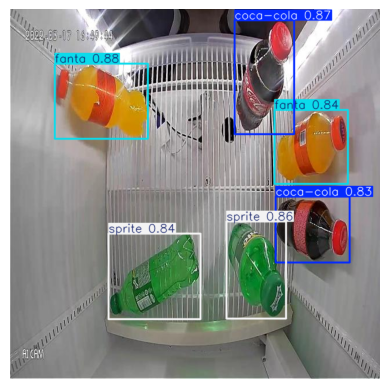

In [12]:
TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")

sample_images = os.listdir(TEST_IMAGES)[:5]

for img_name in sample_images:
    img_path = os.path.join(TEST_IMAGES, img_name)

    results = trained_model(img_path)

    for r in results:
        im_array = r.plot()  # draw boxes
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

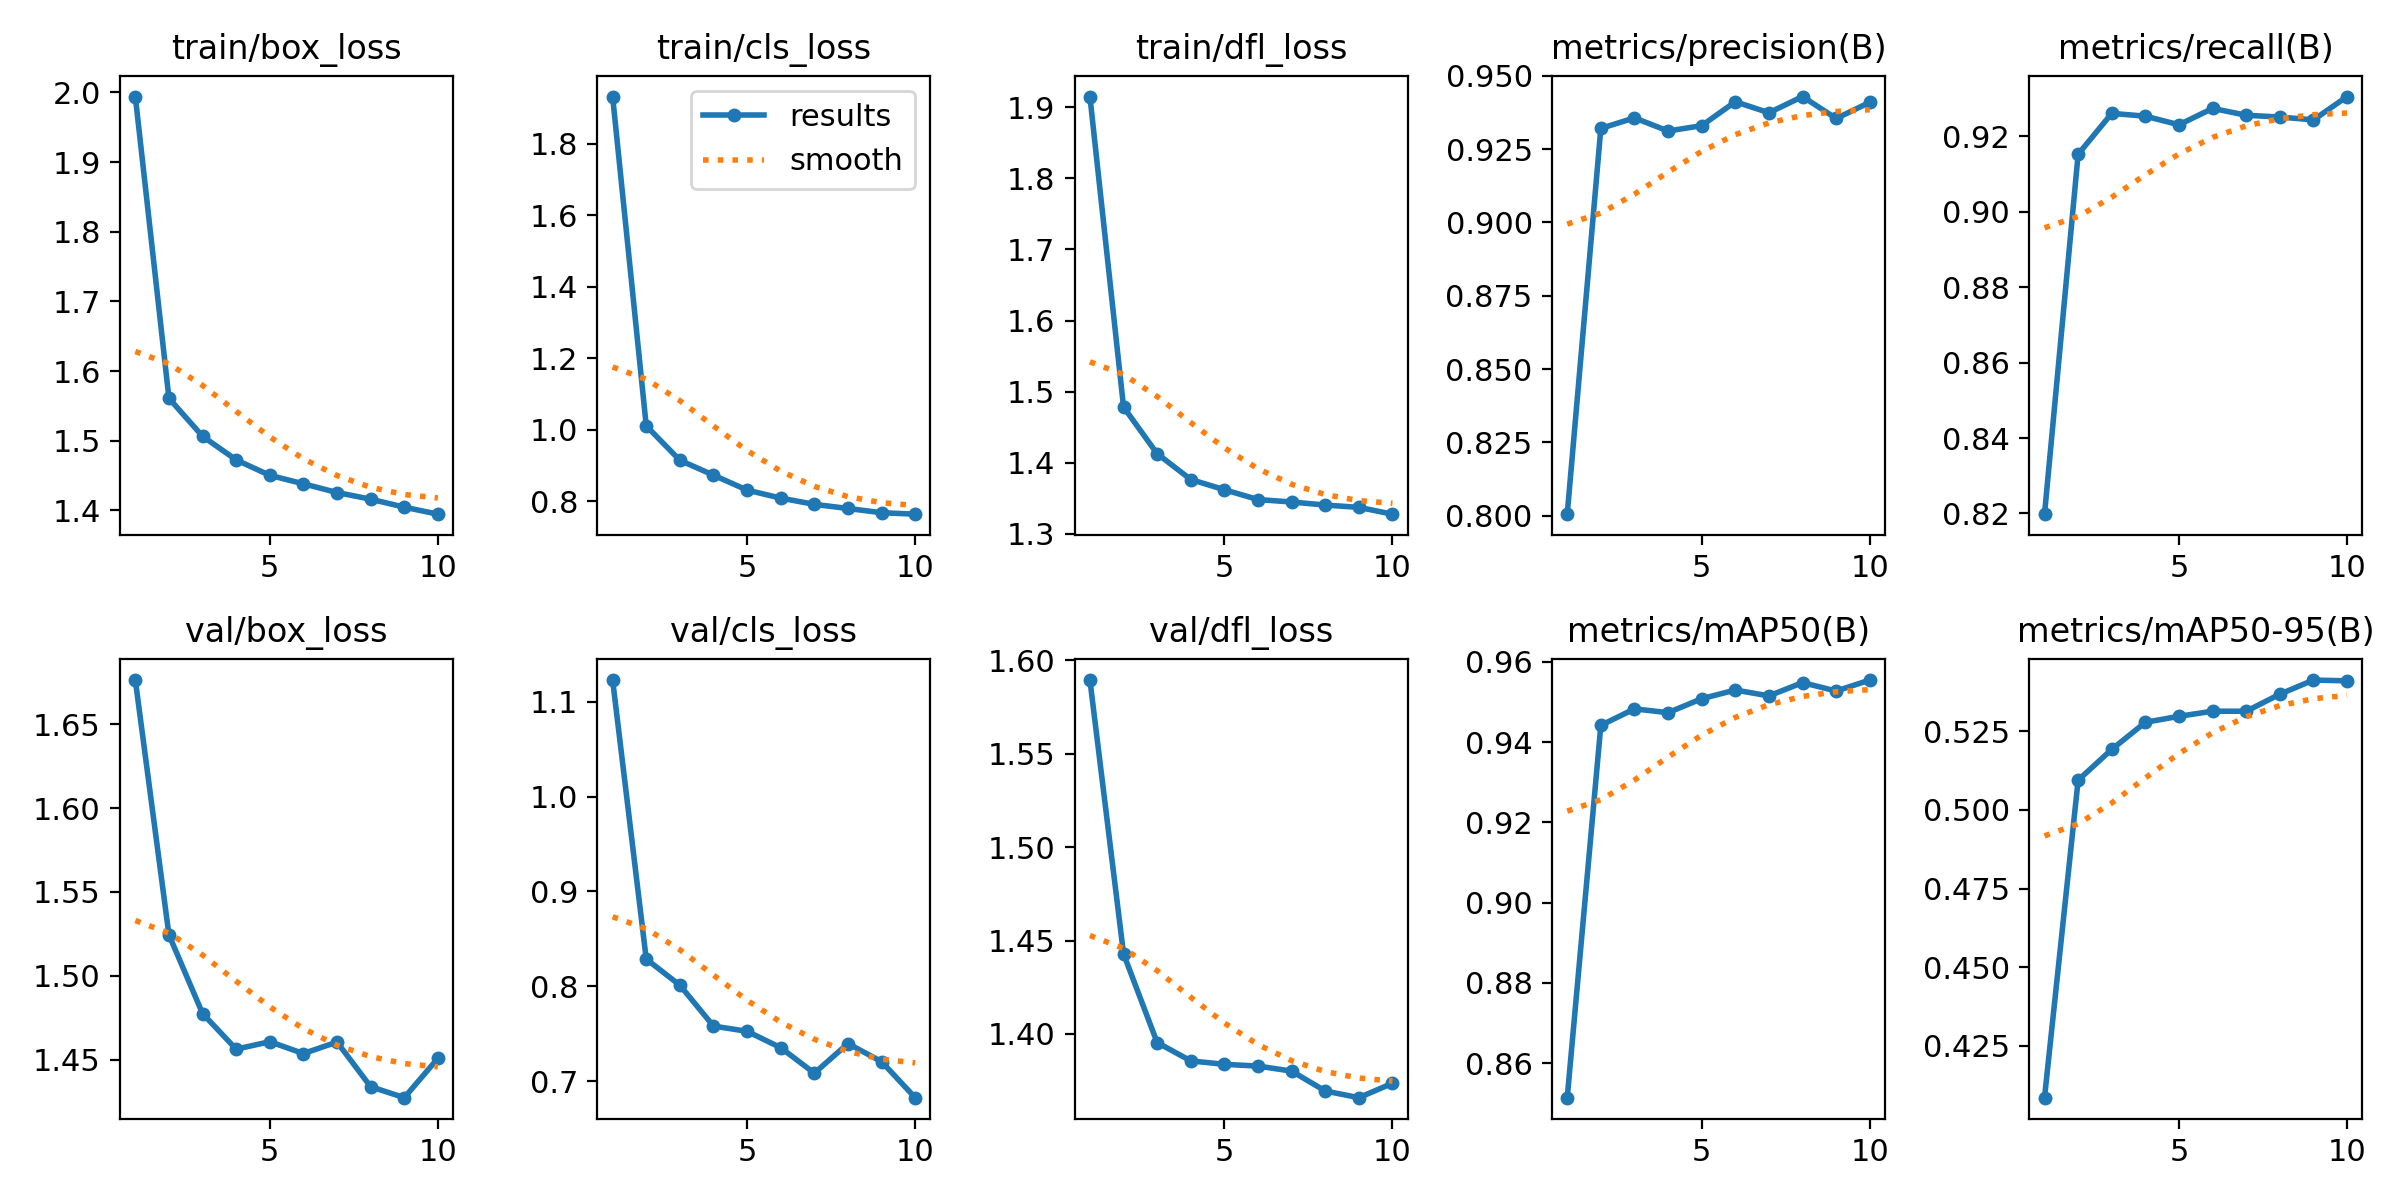

In [14]:
from IPython.display import Image, display

display(Image("/content/runs/detect/yolov8_custom/results.png"))

## using YOLOv8s


In [15]:
model2 = YOLO("yolov8s.pt")   # nano version (fast)

In [16]:
metrics_before = model2.val(data=DATA_YAML)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1493.9±353.5 MB/s, size: 71.8 KB)
val: Scanning /content/soda-bottles-zygh-1/valid/labels.cache... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449 117.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.4it/s 8.6s
                   all        449      10949     0.0769     0.0216     0.0405     0.0223
                person        435       3812     0.0735     0.0538     0.0409     0.0209
               bicycle        439       3441     0.0595    0.00291     0.0299     0.0152
                   car        440       3696     0.0977    0.00812     0.0508     0.0306
Speed: 1.9ms preprocess, 9.5ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/v

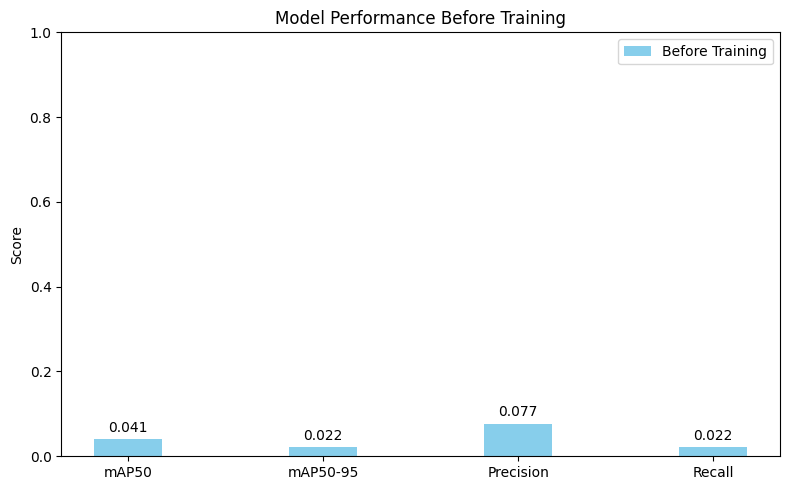

In [17]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_before_values = [
    metrics_before.box.map50,
    metrics_before.box.map,
    metrics_before.box.mp,
    metrics_before.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_before_values, width, label='Before Training', color='skyblue')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [18]:
results = model2.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name="yolov8_custom2"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/soda-bottles-zygh-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [22]:
trained_model2 = YOLO("/content/runs/detect/yolov8_custom2/weights/best.pt")

metrics_after = trained_model.val(data=DATA_YAML)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2007.3±864.8 MB/s, size: 71.8 KB)
val: Scanning /content/soda-bottles-zygh-1/valid/labels.cache... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449 209.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.9it/s 10.0s
                   all        449      10949      0.941      0.931      0.955      0.546
             coca-cola        435       3812      0.937      0.929      0.954      0.538
                 fanta        439       3441      0.943      0.939       0.96      0.561
                sprite        440       3696      0.943      0.926      0.952      0.537
Speed: 2.1ms preprocess, 8.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val5


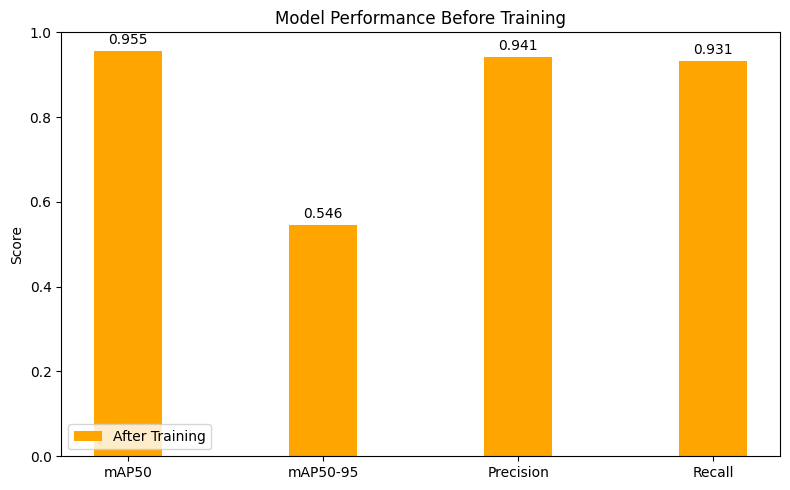

In [23]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_after_values = [
    metrics_after.box.map50,
    metrics_after.box.map,
    metrics_after.box.mp,
    metrics_after.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_after_values, width, label='After Training', color='Orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [21]:
print("\n===== PERFORMANCE COMPARISON =====")

print("mAP50 BEFORE :", metrics_before.box.map50)
print("mAP50 AFTER  :", metrics_after.box.map50)

print("mAP50-95 BEFORE :", metrics_before.box.map)
print("mAP50-95 AFTER  :", metrics_after.box.map)

print("Precision BEFORE :", metrics_before.box.mp)
print("Precision AFTER  :", metrics_after.box.mp)

print("Recall BEFORE :", metrics_before.box.mr)
print("Recall AFTER  :", metrics_after.box.mr)


===== PERFORMANCE COMPARISON =====
mAP50 BEFORE : 0.04052583671824538
mAP50 AFTER  : 0.9553852911889887
mAP50-95 BEFORE : 0.02226828096416293
mAP50-95 AFTER  : 0.5455616513341035
Precision BEFORE : 0.07692436366511861
Precision AFTER  : 0.9410226819051369
Recall BEFORE : 0.02160018655042857
Recall AFTER  : 0.9312570176866869


In [ ]:
TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")

sample_images = os.listdir(TEST_IMAGES)[:5]

for img_name in sample_images:
    img_path = os.path.join(TEST_IMAGES, img_name)

    results = trained_model(img_path)

    for r in results:
        im_array = r.plot()  # draw boxes
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

In [ ]:
from IPython.display import Image, display

display(Image("runs/detect/yolov8_custom2/results.png"))

## using YOLOv8m


In [ ]:
model = YOLO("yolov8n.pt")   # nano version (fast)

In [ ]:
metrics_before = model.val(data=DATA_YAML)

In [ ]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_before_values = [
    metrics_before.box.map50,
    metrics_before.box.map,
    metrics_before.box.mp,
    metrics_before.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_before_values, width, label='Before Training', color='skyblue')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [ ]:
results = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16,
    name="yolov8_custom"
)

In [ ]:
trained_model = YOLO("runs/detect/yolov8_custom/weights/best.pt")

metrics_after = trained_model.val(data=DATA_YAML)

In [ ]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
metrics_after_values = [
    metrics_after.box.map50,
    metrics_after.box.map,
    metrics_after.box.mp,
    metrics_after.box.mr
]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects = ax.bar(x, metrics_after_values, width, label='After Training', color='Orange')

ax.set_ylabel('Score')
ax.set_title('Model Performance Before Training')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0, 1.0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

fig.tight_layout()
plt.show()

In [ ]:
print("\n===== PERFORMANCE COMPARISON =====")

print("mAP50 BEFORE :", metrics_before.box.map50)
print("mAP50 AFTER  :", metrics_after.box.map50)

print("mAP50-95 BEFORE :", metrics_before.box.map)
print("mAP50-95 AFTER  :", metrics_after.box.map)

print("Precision BEFORE :", metrics_before.box.mp)
print("Precision AFTER  :", metrics_after.box.mp)

print("Recall BEFORE :", metrics_before.box.mr)
print("Recall AFTER  :", metrics_after.box.mr)

In [ ]:
TEST_IMAGES = os.path.join(DATASET_PATH, "test/images")

sample_images = os.listdir(TEST_IMAGES)[:5]

for img_name in sample_images:
    img_path = os.path.join(TEST_IMAGES, img_name)

    results = trained_model(img_path)

    for r in results:
        im_array = r.plot()  # draw boxes
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

In [ ]:
from IPython.display import Image, display

display(Image("runs/detect/yolov8_custom2/results.png"))

In [17]:
from ultralytics import YOLO
import os

def train_and_evaluate(model_name, run_name, data_yaml, epochs=10):

    print(f"\n===== Training {model_name} =====")

    model = YOLO(model_name)

    # Train
    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=640,
        batch=16,
        name=run_name
    )

    # Get actual save directory automatically
    save_dir = results.save_dir

    # Build correct best.pt path
    best_model_path = os.path.join(save_dir, "weights", "best.pt")

    # Load trained model safely
    trained_model = YOLO(best_model_path)

    # Validate
    metrics = trained_model.val(data=data_yaml)

    return {
        "Model": model_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr
    }


In [20]:
DATASET_PATH = "/content/soda-bottles-zygh-1"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

results_n = train_and_evaluate("yolov8n.pt", "exp_n", DATA_YAML, epochs=10)
results_s = train_and_evaluate("yolov8s.pt", "exp_s", DATA_YAML, epochs=10)
results_m = train_and_evaluate("yolov8m.pt", "exp_m", DATA_YAML, epochs=10)




===== Training yolov8n.pt =====
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/soda-bottles-zygh-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [23]:
import pandas as pd

comparison_df = pd.DataFrame([results_n, results_s, results_m])
comparison_df


,Model,mAP50,mAP50-95,Precision,Recall
0,yolov8n.pt,0.955358,0.541562,0.938354,0.932035
1,yolov8s.pt,0.954438,0.547696,0.941435,0.930363
2,yolov8m.pt,0.955319,0.550133,0.942430,0.931002


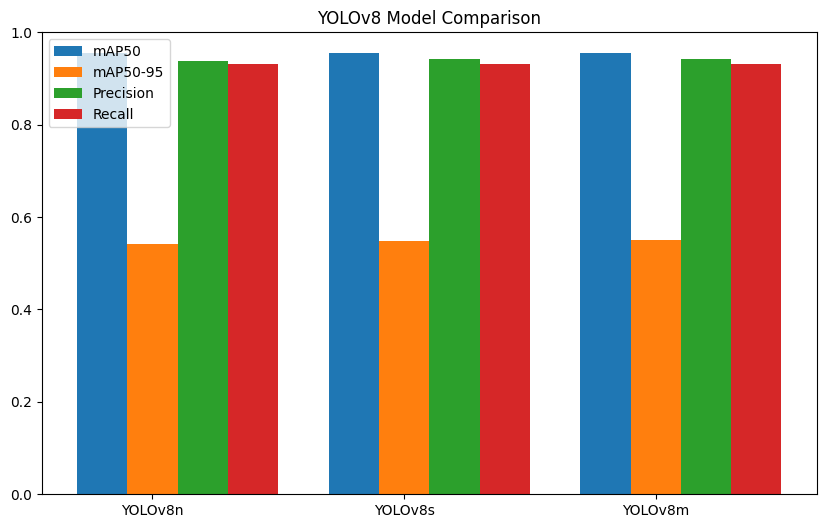

In [22]:
metrics_labels = ['mAP50', 'mAP50-95', 'Precision', 'Recall']

models = ['YOLOv8n', 'YOLOv8s', 'YOLOv8m']

values = [
    [results_n['mAP50'], results_s['mAP50'], results_m['mAP50']],
    [results_n['mAP50-95'], results_s['mAP50-95'], results_m['mAP50-95']],
    [results_n['Precision'], results_s['Precision'], results_m['Precision']],
    [results_n['Recall'], results_s['Recall'], results_m['Recall']]
]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

for i in range(len(metrics_labels)):
    ax.bar(x + i*width, values[i], width, label=metrics_labels[i])

ax.set_xticks(x + width)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_title("YOLOv8 Model Comparison")
ax.legend()

plt.show()
